## Report of HW1
## Rong Gan

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Part F

In [8]:
# read the portfolio simulation results file
data = pd.read_csv("simulation_results.csv")

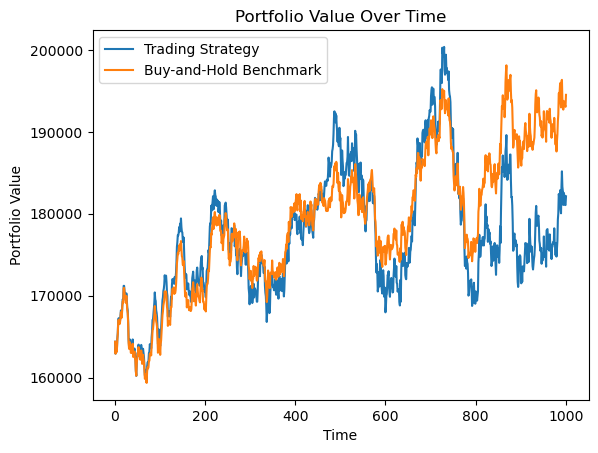

In [9]:
# plot the portfolio value
plt.figure()
plt.plot(data["Time"], data["TradingStrategy"], label = "Trading Strategy")
plt.plot(data["Time"], data["BuyAndHold"], label = "Buy-and-Hold Benchmark")
plt.title("Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

In [13]:
# returns
data["Trading_Return"] = (data["TradingStrategy"].pct_change())
data["BuyHold_Return"] = (data["BuyAndHold"].pct_change())
returns = data.dropna()

# mean returns
trading_mean = returns["Trading_Return"].mean()
buyhold_mean = returns["BuyHold_Return"].mean()
# standard deviation
trading_sd = returns["Trading_Return"].std()
buyhold_sd = returns["BuyHold_Return"].std()

# Annualize mean and std
trading_annual_mean = trading_mean * 252
trading_annual_sd = trading_sd * np.sqrt(252)
buyhold_annual_mean = buyhold_mean * 252
buyhold_annual_sd = buyhold_sd * np.sqrt(252)

results = pd.DataFrame({"Strategy": ["Trading Strategy", "Buy-and-Hold"],
                        "Annualized Mean Return": [trading_annual_mean, buyhold_annual_mean],
                        "Annualized Standard Deviation": [trading_annual_sd, buyhold_annual_sd]})
results

,Strategy,Annualized Mean Return,Annualized Standard Deviation
0,Trading Strategy,0.032099,0.111645
1,Buy-and-Hold,0.046452,0.089145


# Part G

In [4]:
# read and print the reports
data_results = pd.read_csv("report.csv")
data_results

,Item,Result
0,(a) Initial Portfolio Value,163971
1,(b) Final Trading Strategy Value,182121
2,(c) Final Buy-and-Hold Value,194513
3,(d) Total Buy Transactions,135
4,(e) Total Sell Transactions,74
5,(f) Maximum Portfolio Value under Trading Stra...,200363
6,(g) Minimum Portfolio Value under Trading Stra...,159602
7,(h) Most Traded Stock,NVDA
8,(i) Trading Strategy Profitable,Yes
9,(j) Better Strategy,Buy-and-Hold


* **Initial portfolio value**: My initial account value was 163,971, including both the initial cash and the value of the stocks already owned:
100000 + 110(78.54) + 200(189.72) + 100(173.88) = 163971.

* **Portfolio Value Comparision**: Both strategies were profitable because their final portfolio values were higher than the initial portfolio value. Although both portfolio values fluctuate over time, the buy-and-hold strategy performed better in this simulation. Its final value was 194,513, compared with 182,121 for the trading strategy, resulting in an outperformance 12,392.

* **Risk and Return**: I also calculate the return and risk of two portfolios. Buy-and-hold had a higher annualized mean return (4.65%) and a lower annualized standard deviation (8.91%) than the trading strategy, which had an annualized mean return of 3.21% and an annualized standard deviation of 11.16%.

* **Simulation limitation**: In this simulation, the mean-reversion trading strategy did not outperform buy-and-hold. However, this does not necessarily mean that mean-reversion strategies are always inferior. The results depend on the randomly generated price paths. Different random seeds can produce different returns, portfolio values, and trading results. Therefore, one simulation alone is not sufficient to conclude that one strategy will always outperform the other.

* **Most Traded Stock**: NVDA generated the most trades, which is reasonable because NVDA is designed to have the highest volatility among the three stocks. Its larger price movements make it more likely to reach the buying and selling thresholds.

* **Strength of the Strategy**: The mean-reversion strategy uses simple and intuitive trading rules. It buys after relatively large price declines and sells after relatively large price increases, which is easy for investors to make decisions.

* **Weakness of the strategy**: The strategy may perform poorly when stock prices exhibit a sustained upward or downward trend. Selling after a price increase may cause the portfolio to reduce its position in stocks that continue to rise. Also, the thresholds for buying and selling are ad hoc, which can affect the results significantly when trading different assets.
